In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.stats import (
    ttest_ind,
    t,
    f_oneway
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [13]:
np.random.seed(1)

In [14]:
# Loading dataset.

iris = load_iris(as_frame=True)

df = iris.frame

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [15]:
# Looking for variables.

print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')


In [16]:
# Data Inspection

# Checking dimensions.

print("Data shape: ", df.shape)

# Checking missing values.

print("\nNumber of missing values:\n", df.isnull().sum())

Data shape:  (150, 5)

Number of missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [17]:
# Descriptive Statistics

# Overall:

print("Overall descriptives:\n", df.describe())

# Group:

print(
    "\nGroup descriptives:\n",
    df.groupby("target").mean()
)

Overall descriptives:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Group descriptives:
         sepal length (cm)  

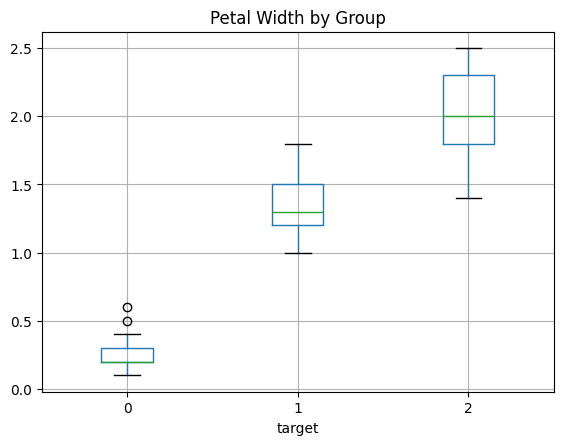

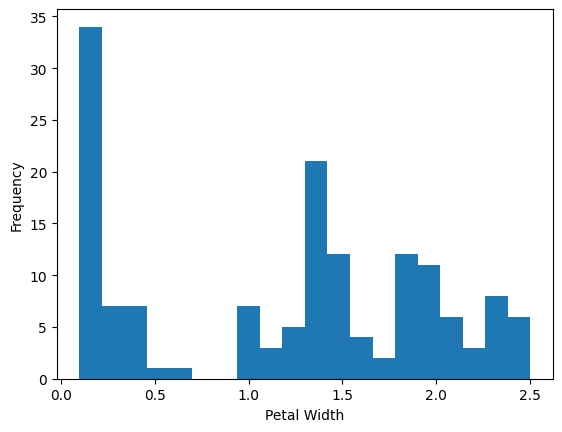

In [18]:
# Visualizing.

# Boxplot

df.boxplot(
    column="petal width (cm)",
    by="target"
)

plt.title("Petal Width by Group")
plt.suptitle("")

plt.show()

# Histogram

plt.hist(df["petal width (cm)"], bins=20)

plt.xlabel("Petal Width")
plt.ylabel("Frequency")

plt.show()

Question: do Setosa and Versicolor differ in petal width?

In [19]:
# Extracting the groups.

group0 = df[
    df["target"] == 0
]["petal width (cm)"]

group1 = df[
    df["target"] == 1
]["petal width (cm)"]

# Running a t-test.

result = ttest_ind(group0, group1)

print(result)

TtestResult(statistic=np.float64(-34.08034154357719), pvalue=np.float64(3.831095388248147e-56), df=np.float64(98.0))


In [20]:
# Computing pooled SD.

pooled_sd = np.sqrt(
    ((len(group0)-1) * np.var(group0,ddof=1)
        +
        (len(group1)-1) * np.var(group1,ddof=1))
    /
    (len(group0) + len(group1) - 2)
)

# Computing Cohen's d.

d = (np.mean(group0) - np.mean(group1)) / pooled_sd

print("Cohen d:", d)

Cohen d: -6.816068308715439


In [22]:
# Computing means difference:

mean_diff = (np.mean(group0) -np.mean(group1))

# Computing SE.

se = pooled_sd * np.sqrt(1/len(group0) + 1/len(group1))

# Computing critical value.

dfree = (len(group0) + len(group1) - 2)

critical = t.ppf(.975, dfree)

# Computing CI.

lower = mean_diff - critical*se

upper = mean_diff + critical*se

print("CI: ", lower, upper)

CI:  -1.142887422889489 -1.0171125771105107


In [34]:
# Creating a results table.

results = pd.DataFrame({

    "Group":[
        "Setosa",
        "Versicolor"
    ],

    "Mean":[
        group0.mean(),
        group1.mean()
    ],

    "SD":[
        group0.std(),
        group1.std()
    ],

    "N":[
        len(group0),
        len(group1)
    ]
})

print("Results table:\n", results)

Results table:
         Group   Mean        SD   N
0      Setosa  0.246  0.105386  50
1  Versicolor  1.326  0.197753  50


#### APA Report

t(98) = -34.08

p < .001

d = -6.8

95% CI
[-1.14,-1.01]

Report: an independent-samples t-test revealed that Setosa flowers (M = 0.25, SD = 0.10) had smaller petal widths than Versicolor flowers (M = 1.33, SD = 0.20), t(98) = -34.08, p < .001, d = -6.80, 95% CI [-1.14, -1.01].

In [32]:
# Creating three groups for ANOVA.

setosa = df[df.target==0]["petal width (cm)"]

versicolor = df[df.target==1]["petal width (cm)"]

virginica = df[df.target==2]["petal width (cm)"]

# Running an ANOVA test.

F,p = f_oneway(
    setosa,
    versicolor,
    virginica
)

print("F:", F, "\np:", p)

F: 960.0071468018067 
p: 4.169445839443882e-85


In [33]:
# Running a tukey test.

tukey = pairwise_tukeyhsd(
    df["petal width (cm)"],
    df["target"]
)

print("Tukey:\n", tukey)

Tukey:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     0      1     1.08   0.0 0.9831 1.1769   True
     0      2     1.78   0.0 1.6831 1.8769   True
     1      2      0.7   0.0 0.6031 0.7969   True
-------------------------------------------------
